In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
plant_data = pd.read_csv('../data/final_dataset.csv')
plant_data

,ORISPL,YEAR,PSTATABB,NAMEPCAP,CAPFAC,SECTOR,PLFUELCT,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
0,55279,2020,IL,1086.2,0.0808,IPP Non-CHP,GAS,768846.0,7770819.0,461804.0,1201.292,0,0,0
1,55296,2020,IL,312.8,0.0053,IPP Non-CHP,GAS,14431.0,155609.0,9039.0,1252.678,0,0,0
2,55188,2020,IL,611.2,0.3719,IPP Non-CHP,GAS,1990983.0,13538133.0,804563.0,808.206,0,0,0
3,55253,2020,IL,356.0,0.0122,IPP Non-CHP,GAS,37942.0,500498.0,29739.0,1567.619,0,0,0
4,55438,2020,IL,540.0,0.0800,IPP Non-CHP,GAS,378234.0,4420334.0,262695.0,1389.061,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,3948,2021,WV,1632.6,0.3335,Electric Utility,COAL,4769104.0,49696486.0,5098240.0,2138.029,0,1,1
848,3954,2021,WV,1680.9,0.3741,Electric Utility,COAL,5508707.0,57367773.0,5885931.0,2136.956,0,1,1
849,6264,2021,WV,1300.0,0.6263,Electric Utility,COAL,7132758.0,71684682.0,7353642.0,2061.935,0,1,1
850,55349,2021,WV,344.0,0.4156,IPP Non-CHP,GAS,1252463.0,13022037.0,774961.0,1237.499,0,1,1


In [3]:
plant_data.describe()

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
count,852.000000,852.000000,852.000000,852.000000,8.520000e+02,8.520000e+02,8.520000e+02,852.000000,852.000000,852.000000,852.000000
mean,30521.915493,2020.433099,690.115023,0.256942,2.021913e+06,1.788269e+07,1.473947e+06,1773.645062,0.241784,0.147887,0.483568
std,25689.993570,1.717124,631.325974,0.268452,2.994570e+06,2.689300e+07,2.565978e+06,4781.255351,0.428416,0.355197,0.500023
min,54.000000,2018.000000,25.000000,0.000000,-5.759600e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,3799.000000,2019.000000,126.600000,0.021325,5.371550e+04,5.607055e+05,3.097650e+04,865.439500,0.000000,0.000000,0.000000
50%,50481.000000,2020.000000,557.300000,0.121700,4.570030e+05,4.374530e+06,2.615995e+05,1372.982500,0.000000,0.000000,0.000000
75%,55297.000000,2022.000000,1067.675000,0.499675,3.505229e+06,2.824328e+07,1.833407e+06,2061.324500,0.000000,0.000000,1.000000
max,63931.000000,2023.000000,2932.600000,0.872100,1.600620e+07,1.541848e+08,1.581832e+07,132035.700000,1.000000,1.000000,1.000000


In [4]:
treat_0 = plant_data.loc[plant_data["TREATED"] == 0].describe()
treat_1 = plant_data.loc[plant_data["TREATED"] == 1].describe()

treat_0

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
count,646.000000,646.000000,646.000000,646.000000,6.460000e+02,6.460000e+02,6.460000e+02,646.000000,646.0,646.000000,646.000000
mean,30549.554180,2020.436533,711.320588,0.263228,2.127461e+06,1.944155e+07,1.682216e+06,1879.137478,0.0,0.195046,0.484520
std,25992.879913,1.715817,662.836881,0.272168,3.087603e+06,2.884873e+07,2.842847e+06,5465.635200,0.0,0.396543,0.500148
min,54.000000,2018.000000,25.000000,0.000000,-5.759600e+04,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000
25%,2917.000000,2019.000000,115.500000,0.021225,5.080575e+04,5.204972e+05,3.017000e+04,872.070500,0.0,0.000000,0.000000
50%,50481.000000,2020.000000,571.800000,0.127050,4.634890e+05,4.452430e+06,2.818915e+05,1434.439000,0.0,0.000000,0.000000
75%,55296.000000,2022.000000,1150.000000,0.517300,3.930108e+06,3.307285e+07,2.243746e+06,2096.872500,0.0,0.000000,1.000000
max,63931.000000,2023.000000,2932.600000,0.842700,1.600620e+07,1.541848e+08,1.581832e+07,132035.700000,0.0,1.000000,1.000000


In [5]:
treat_1

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
count,206.000000,206.000000,206.000000,206.000000,2.060000e+02,2.060000e+02,2.060000e+02,206.000000,206.0,206.0,206.000000
mean,30435.242718,2020.422330,623.616019,0.237230,1.690922e+06,1.299421e+07,8.208314e+05,1442.829039,1.0,0.0,0.480583
std,24777.656537,1.725359,516.088605,0.256090,2.661892e+06,1.876404e+07,1.157272e+06,873.109619,0.0,0.0,0.500840
min,3775.000000,2018.000000,27.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,1.0,0.0,0.000000
25%,7032.000000,2019.000000,254.200000,0.021575,5.719725e+04,6.676122e+05,3.211550e+04,848.173250,1.0,0.0,0.000000
50%,10633.000000,2020.000000,475.000000,0.110600,4.266650e+05,3.726636e+06,2.078860e+05,1230.509000,1.0,0.0,0.000000
75%,55381.000000,2022.000000,848.000000,0.446125,2.385013e+06,1.702965e+07,1.314001e+06,1712.831250,1.0,0.0,1.000000
max,59913.000000,2023.000000,2081.900000,0.872100,1.151319e+07,7.504928e+07,4.460053e+06,5821.306000,1.0,0.0,1.000000


In [6]:
post_0 = plant_data.loc[plant_data["POST"] == 0].describe()
post_1 = plant_data.loc[plant_data["POST"] == 1].describe()

post_0

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
count,440.000000,440.000000,440.000000,440.000000,4.400000e+02,4.400000e+02,4.400000e+02,440.000000,440.000000,440.000000,440.0
mean,29495.947727,2018.972727,702.824091,0.244157,1.928073e+06,1.713003e+07,1.427271e+06,1608.267995,0.243182,0.150000,0.0
std,25580.005450,0.817899,654.918900,0.269359,2.997922e+06,2.703670e+07,2.593430e+06,1249.071399,0.429492,0.357478,0.0
min,54.000000,2018.000000,26.100000,0.000000,-5.759600e+04,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.0
25%,3796.000000,2018.000000,125.700000,0.017700,4.187575e+04,4.749610e+05,2.785250e+04,874.092500,0.000000,0.000000,0.0
50%,10633.000000,2019.000000,555.600000,0.092350,3.734475e+05,4.076066e+06,2.433935e+05,1414.362000,0.000000,0.000000,0.0
75%,55284.000000,2020.000000,1088.850000,0.476200,3.206499e+06,2.698462e+07,1.684642e+06,2059.050250,0.000000,0.000000,0.0
max,60376.000000,2020.000000,2932.600000,0.872100,1.600620e+07,1.541848e+08,1.581832e+07,17016.263000,1.000000,1.000000,0.0


In [7]:
post_1

,ORISPL,YEAR,NAMEPCAP,CAPFAC,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
count,412.000000,412.000000,412.000000,412.000000,4.120000e+02,4.120000e+02,4.120000e+02,412.000000,412.000000,412.000000,412.0
mean,31617.609223,2021.992718,676.542233,0.270595,2.122129e+06,1.868650e+07,1.523795e+06,1950.261347,0.240291,0.145631,1.0
std,25792.915018,0.817953,605.616213,0.267131,2.991374e+06,2.674812e+07,2.538534e+06,6753.281356,0.427780,0.353165,0.0
min,54.000000,2021.000000,25.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,1.0
25%,3803.000000,2021.000000,126.600000,0.028275,6.173975e+04,6.477628e+05,3.590900e+04,858.928250,0.000000,0.000000,1.0
50%,52019.000000,2022.000000,559.000000,0.160900,5.426465e+05,5.165656e+06,3.209535e+05,1349.639500,0.000000,0.000000,1.0
75%,55350.000000,2023.000000,1061.500000,0.514825,3.641665e+06,3.031337e+07,2.082884e+06,2065.845250,0.000000,0.000000,1.0
max,63931.000000,2023.000000,2932.600000,0.842700,1.380673e+07,1.436609e+08,1.473606e+07,132035.700000,1.000000,1.000000,1.0


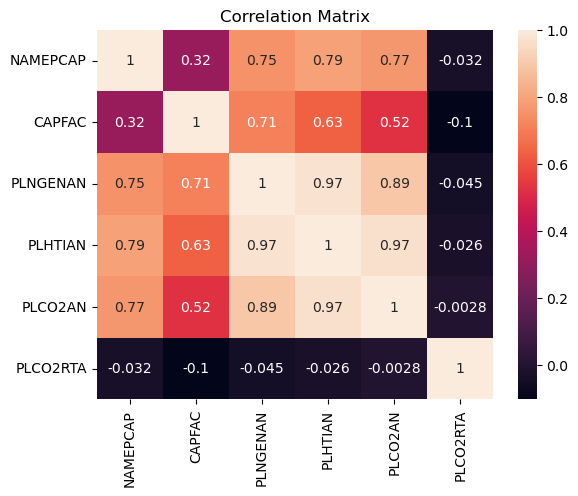

In [8]:
## Correlation Matrix
corr_matrix = plant_data[['NAMEPCAP','CAPFAC','PLNGENAN','PLHTIAN', 'PLCO2AN', 'PLCO2RTA']].corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Matrix')
plt.savefig('../figures/correlation_matrix.png')
plt.show()

In [9]:
plant_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ORISPL    852 non-null    int64  
 1   YEAR      852 non-null    int64  
 2   PSTATABB  852 non-null    object 
 3   NAMEPCAP  852 non-null    float64
 4   CAPFAC    852 non-null    float64
 5   SECTOR    852 non-null    object 
 6   PLFUELCT  852 non-null    object 
 7   PLNGENAN  852 non-null    float64
 8   PLHTIAN   852 non-null    float64
 9   PLCO2AN   852 non-null    float64
 10  PLCO2RTA  852 non-null    float64
 11  TREATED   852 non-null    int64  
 12  NEIGHBOR  852 non-null    int64  
 13  POST      852 non-null    int64  
dtypes: float64(6), int64(5), object(3)
memory usage: 93.3+ KB


In [10]:
plant_data

,ORISPL,YEAR,PSTATABB,NAMEPCAP,CAPFAC,SECTOR,PLFUELCT,PLNGENAN,PLHTIAN,PLCO2AN,PLCO2RTA,TREATED,NEIGHBOR,POST
0,55279,2020,IL,1086.2,0.0808,IPP Non-CHP,GAS,768846.0,7770819.0,461804.0,1201.292,0,0,0
1,55296,2020,IL,312.8,0.0053,IPP Non-CHP,GAS,14431.0,155609.0,9039.0,1252.678,0,0,0
2,55188,2020,IL,611.2,0.3719,IPP Non-CHP,GAS,1990983.0,13538133.0,804563.0,808.206,0,0,0
3,55253,2020,IL,356.0,0.0122,IPP Non-CHP,GAS,37942.0,500498.0,29739.0,1567.619,0,0,0
4,55438,2020,IL,540.0,0.0800,IPP Non-CHP,GAS,378234.0,4420334.0,262695.0,1389.061,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
847,3948,2021,WV,1632.6,0.3335,Electric Utility,COAL,4769104.0,49696486.0,5098240.0,2138.029,0,1,1
848,3954,2021,WV,1680.9,0.3741,Electric Utility,COAL,5508707.0,57367773.0,5885931.0,2136.956,0,1,1
849,6264,2021,WV,1300.0,0.6263,Electric Utility,COAL,7132758.0,71684682.0,7353642.0,2061.935,0,1,1
850,55349,2021,WV,344.0,0.4156,IPP Non-CHP,GAS,1252463.0,13022037.0,774961.0,1237.499,0,1,1
